### Что делаем:
| Шаг | Описание |
|-----|----------|
| 1 | Загружаем все 3 класса (`depression`, `anxiety`, `neutral`) вместе |
| 2 | Строим два типа представлений: **TF-IDF** (лексический) и **SBERT** (семантический) |
| 3 | Кластеризуем тремя алгоритмами: **K-Means**, **Agglomerative**, **HDBSCAN** |
| 4 | Оцениваем качество: **Silhouette**, **Davies-Bouldin**, **ARI** (согласие с разметкой) |
| 5 | Визуализируем в 2D через **UMAP** и **t-SNE** |
| 6 | Описываем кластеры: топ-слова (TF-IDF) + примеры текстов |

### Ключевой вопрос для ВКР:
> Совпадают ли кластеры, найденные **без знания меток**, с классами словарной разметки (depression / anxiety / neutral)? Если да — это подтверждает, что языковые различия между классами реальны и устойчивы.

In [2]:
# 0. Установка

!pip install -q sentence-transformers
!pip install -q umap-learn
!pip install -q openpyxl
print('Готово ✓')

import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

# Векторизация
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Кластеризация
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize

# Метрики
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score,
    confusion_matrix, classification_report
)

# Снижение размерности
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD, PCA
import umap

# Дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

import openpyxl
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

print('Импорты ✓')

from google.colab import drive
drive.mount('/content/drive')

Готово ✓
Импорты ✓
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# 1. Загрузка данных: лемматизированные (TF-IDF) и оригинальные (SBERT)

from pathlib import Path
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── ПУТИ ─────────────────────────────────────────────────────────────────
LEMMATIZED_DIR = Path('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/(FOR USE) После удаления одинаковых/labeled_clean')
ORIGINAL_DIR   = Path('/content/drive/MyDrive/SFU 4/VKR/8. Clustering/not_lemma')  # папка с оригинальными текстами
SAVE_DIR       = Path('/content/drive/MyDrive/SFU 4/VKR/8. Clustering')
# ─────────────────────────────────────────────────────────────────────────

SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['depression', 'anxiety', 'neutral']
LABEL_MAP = {'depression': 0, 'anxiety': 1, 'neutral': 2}
COLORS = {'depression': '#e74c3c', 'anxiety': '#3498db', 'neutral': '#95a5a6'}
MIN_TOKENS = 5

def load_texts_lemma(label):
    """Загружает лемматизированные тексты из labeled_clean"""
    texts = []
    folder = LEMMATIZED_DIR / label
    if not folder.exists():
        return texts
    for fpath in sorted(folder.glob('*.txt')):
        try:
            text = fpath.read_text(encoding='utf-8').strip()
            # Очистка
            text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', text)
            text = re.sub(r'\s+', ' ', text).strip().lower()
            tokens = [t for t in text.split() if len(t) > 2]
            if len(tokens) >= MIN_TOKENS:
                texts.append(text)
        except Exception:
            pass
    return texts

def load_texts_original(label):
    """Загружает оригинальные тексты из not_lemma"""
    texts = []
    folder = ORIGINAL_DIR / label
    if not folder.exists():
        return texts
    for fpath in sorted(folder.glob('*.txt')):
        try:
            text = fpath.read_text(encoding='utf-8').strip()
            text = re.sub(r'\s+', ' ', text).strip()
            if len(text) > 20:  # минимальная длина
                texts.append(text)
        except Exception:
            pass
    return texts

print('='*60)
print('ЗАГРУЗКА ДАННЫХ')
print('='*60)

# Загружаем оба типа текстов
all_texts_lemma = []      # для TF-IDF
all_texts_original = []   # для SBERT
all_labels = []
all_label_names = []

for cls in CLASSES:
    lemma_texts = load_texts_lemma(cls)
    original_texts = load_texts_original(cls)

    # Берём минимальное количество (чтобы пары совпадали)
    n = min(len(lemma_texts), len(original_texts))

    if n < len(lemma_texts):
        print(f'⚠️ {cls}: лемматизированных={len(lemma_texts)}, оригинальных={len(original_texts)} → берём {n}')

    all_texts_lemma.extend(lemma_texts[:n])
    all_texts_original.extend(original_texts[:n])
    all_labels.extend([LABEL_MAP[cls]] * n)
    all_label_names.extend([cls] * n)

    print(f'{cls}: {n} текстов (лемма) | {n} текстов (оригинал)')

all_labels = np.array(all_labels)
print(f'\nИтого: {len(all_texts_lemma)} текстов (TF-IDF) | {len(all_texts_original)} текстов (SBERT)')
print(f'Распределение по классам: {pd.Series(all_label_names).value_counts().to_dict()}')

# DataFrame для удобства
df = pd.DataFrame({
    'text_lemma': all_texts_lemma,
    'text_original': all_texts_original,
    'label': all_labels,
    'label_name': all_label_names
})

print('\n✅ Данные загружены!')

ЗАГРУЗКА ДАННЫХ
depression: 1911 текстов (лемма) | 1911 текстов (оригинал)
anxiety: 601 текстов (лемма) | 601 текстов (оригинал)
neutral: 3801 текстов (лемма) | 3801 текстов (оригинал)

Итого: 6313 текстов (TF-IDF) | 6313 текстов (SBERT)
Распределение по классам: {'neutral': 3801, 'depression': 1911, 'anxiety': 601}

✅ Данные загружены!


In [19]:
# 2. Векторизация TF-IDF (на лемматизированных текстах)

print('\n' + '='*60)
print('TF-IDF ВЕКТОРИЗАЦИЯ (лемматизированные тексты)')
print('='*60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

print('Строим TF-IDF матрицу...')
tfidf = TfidfVectorizer(
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=30000
)
X_tfidf_sparse = tfidf.fit_transform(all_texts_lemma)
print(f'TF-IDF матрица: {X_tfidf_sparse.shape}')

print('Снижаем размерность через SVD (LSA) до 300 компонент...')
svd = TruncatedSVD(n_components=300, random_state=42)
X_tfidf = svd.fit_transform(X_tfidf_sparse)
X_tfidf = normalize(X_tfidf)
print(f'После SVD: {X_tfidf.shape}')
print(f'Объяснённая дисперсия: {svd.explained_variance_ratio_.sum():.3f}')

# 2.1. Векторизация SBERT (на оригинальных текстах)

print('\n' + '='*60)
print('SBERT ВЕКТОРИЗАЦИЯ (оригинальные тексты)')
print('='*60)

from sentence_transformers import SentenceTransformer

print('Загружаем модель DeepPavlov/rubert-base-cased-sentence...')
sbert_model = SentenceTransformer('DeepPavlov/rubert-base-cased-sentence')

print(f'Кодируем {len(all_texts_original)} текстов...')
X_sbert = sbert_model.encode(
    all_texts_original,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
print(f'SBERT матрица: {X_sbert.shape}')

# Сохраняем эмбеддинги
np.save(str(SAVE_DIR / 'sbert_embeddings.npy'), X_sbert)
print('✅ Эмбеддинги сохранены')

print('\n✅ Векторизация завершена!')
print(f'TF-IDF: {X_tfidf.shape}')
print(f'SBERT: {X_sbert.shape}')


TF-IDF ВЕКТОРИЗАЦИЯ (лемматизированные тексты)
Строим TF-IDF матрицу...
TF-IDF матрица: (6313, 18690)
Снижаем размерность через SVD (LSA) до 300 компонент...


После SVD: (6313, 300)
Объяснённая дисперсия: 0.254

SBERT ВЕКТОРИЗАЦИЯ (оригинальные тексты)
Загружаем модель DeepPavlov/rubert-base-cased-sentence...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Кодируем 6313 текстов...


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

SBERT матрица: (6313, 768)
✅ Эмбеддинги сохранены

✅ Векторизация завершена!
TF-IDF: (6313, 300)
SBERT: (6313, 768)


UMAP для TF-IDF...
UMAP для SBERT...
t-SNE для TF-IDF...
t-SNE для SBERT...
Готово ✓


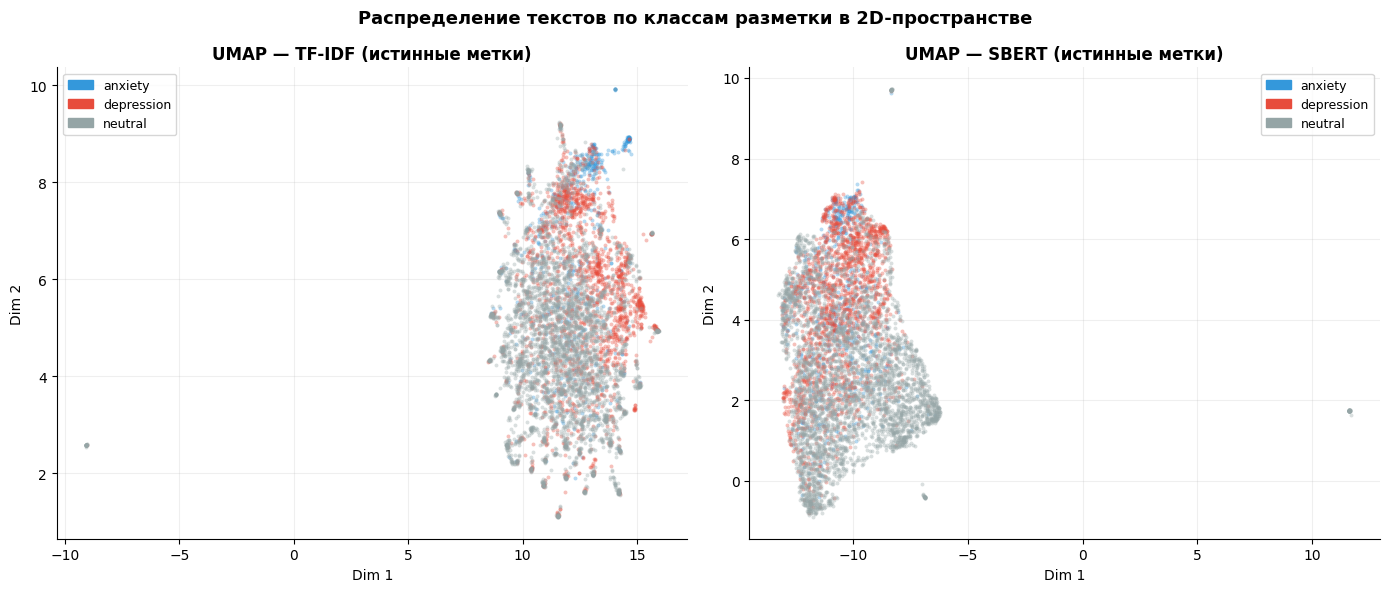

Сохранено: umap_true_labels.png


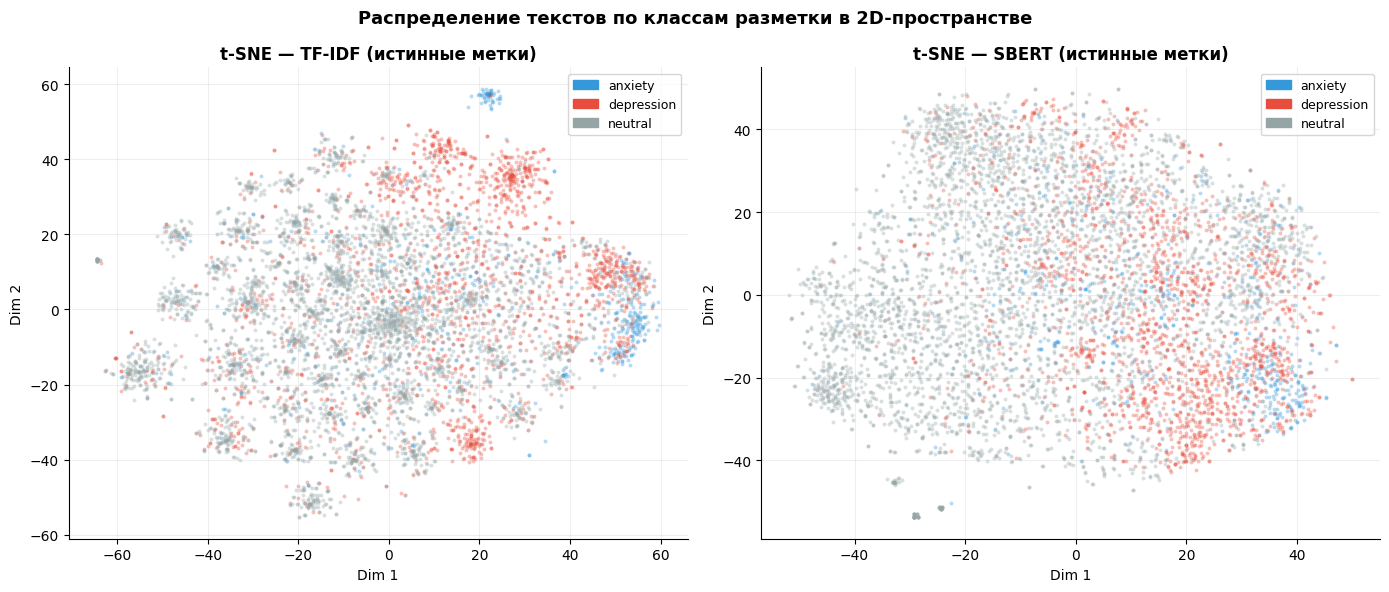

Сохранено: tsne_true_labels.png


In [20]:
# 3. Снижение размерности для визуализации: UMAP и t-SNE

"""
Снижаем до 2D только для **визуализации** — кластеризация будет на полных векторах.

- **UMAP** — быстрее, лучше сохраняет глобальную структуру, красивее
- **t-SNE** — классика, хорошо показывает локальные кластеры
"""

def reduce_umap(X, n_neighbors=30, min_dist=0.1, seed=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='cosine',
        random_state=seed
    )
    return reducer.fit_transform(X)

def reduce_tsne(X, perplexity=50, seed=42):
    # t-SNE не любит >50 измерений — сначала PCA/SVD до 50
    if X.shape[1] > 50:
        pca = PCA(n_components=50, random_state=seed)
        X = pca.fit_transform(X)
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate='auto',
        init='pca',
        random_state=seed,
        n_jobs=-1
    ).fit_transform(X)

print('UMAP для TF-IDF...')
umap_tfidf = reduce_umap(X_tfidf)
print('UMAP для SBERT...')
umap_sbert = reduce_umap(X_sbert)
print('t-SNE для TF-IDF...')
tsne_tfidf = reduce_tsne(X_tfidf)
print('t-SNE для SBERT...')
tsne_sbert = reduce_tsne(X_sbert)
print('Готово ✓')

def plot_embeddings_by_label(coords_list, titles, labels, label_names,
                              colors, save_path):
    """Визуализирует 2D-проекции, раскрашенные по истинным меткам разметки."""
    n = len(coords_list)
    fig, axes = plt.subplots(1, n, figsize=(n * 7, 6))
    if n == 1:
        axes = [axes]

    unique_labels = sorted(set(label_names))
    handles = [mpatches.Patch(color=colors[l], label=l) for l in unique_labels]

    for ax, coords, title in zip(axes, coords_list, titles):
        for lname in unique_labels:
            mask = np.array(label_names) == lname
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                c=colors[lname], alpha=0.35, s=8,
                linewidths=0, label=lname, rasterized=True
            )
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Dim 1')
        ax.set_ylabel('Dim 2')
        ax.legend(handles=handles, fontsize=9, markerscale=3)
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Распределение текстов по классам разметки в 2D-пространстве',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {save_path.name}')


# UMAP: TF-IDF vs SBERT — по истинным меткам
plot_embeddings_by_label(
    [umap_tfidf, umap_sbert],
    ['UMAP — TF-IDF (истинные метки)', 'UMAP — SBERT (истинные метки)'],
    all_labels, all_label_names, COLORS,
    SAVE_DIR / 'umap_true_labels.png'
)

# t-SNE: TF-IDF vs SBERT — по истинным меткам
plot_embeddings_by_label(
    [tsne_tfidf, tsne_sbert],
    ['t-SNE — TF-IDF (истинные метки)', 't-SNE — SBERT (истинные метки)'],
    all_labels, all_label_names, COLORS,
    SAVE_DIR / 'tsne_true_labels.png'
)

Подбираем K для TF-IDF...


K-Means TF-IDF:   0%|          | 0/9 [00:00<?, ?it/s]

Подбираем K для SBERT...


K-Means SBERT:   0%|          | 0/9 [00:00<?, ?it/s]

TF-IDF: лучший K по silhouette = 8  (score=0.0050)
SBERT: лучший K по silhouette = 2  (score=0.2318)


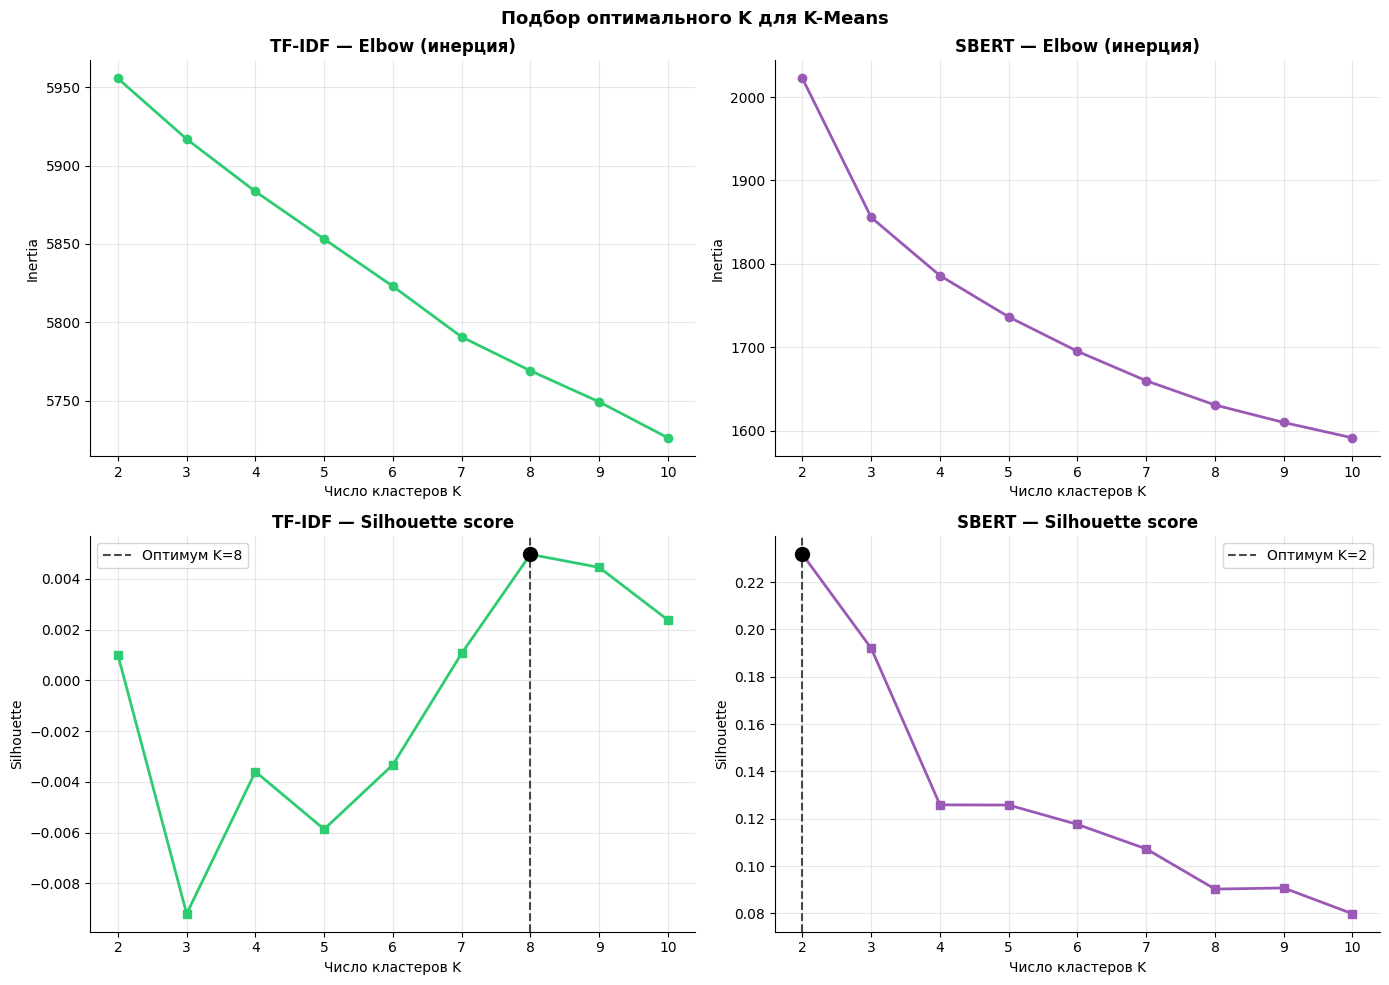

In [21]:
# 4. Подбор оптимального K для K-Means

"""
Используем два критерия:
- **Elbow method** (инерция) — ищем «локоть» на графике
- **Silhouette score** — ищем максимум

Проверяем K от 2 до 10. Ожидаем оптимум около **K=3** (у нас 3 класса), но важно проверить.
"""

def find_optimal_k(X, label, k_range=range(2, 11), sample_size=3000):
    """Подбор K через elbow + silhouette. Используем выборку для скорости."""
    # Для silhouette считаем на выборке (дорогая операция)
    if X.shape[0] > sample_size:
        idx = np.random.RandomState(42).choice(X.shape[0], sample_size, replace=False)
        X_sample = X[idx]
    else:
        X_sample = X

    inertias, silhouettes = [], []
    for k in tqdm(k_range, desc=f'K-Means {label}'):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        labels_pred = km.predict(X_sample)
        sil = silhouette_score(X_sample, labels_pred, metric='cosine')
        silhouettes.append(sil)
    return list(k_range), inertias, silhouettes


print('Подбираем K для TF-IDF...')
k_range_t, inertia_t, sil_t = find_optimal_k(X_tfidf, 'TF-IDF')
print('Подбираем K для SBERT...')
k_range_s, inertia_s, sil_s = find_optimal_k(X_sbert, 'SBERT')

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (label, k_range, inertias, silhouettes, color) in enumerate([
    ('TF-IDF', k_range_t, inertia_t, sil_t, '#2ecc71'),
    ('SBERT',  k_range_s, inertia_s, sil_s, '#9b59b6'),
]):
    best_k_sil = k_range[silhouettes.index(max(silhouettes))]

    # Elbow
    ax = axes[0, col]
    ax.plot(k_range, inertias, 'o-', color=color, lw=2)
    ax.set_title(f'{label} — Elbow (инерция)', fontweight='bold')
    ax.set_xlabel('Число кластеров K')
    ax.set_ylabel('Inertia')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Silhouette
    ax2 = axes[1, col]
    ax2.plot(k_range, silhouettes, 's-', color=color, lw=2)
    ax2.axvline(best_k_sil, color='black', ls='--', alpha=0.7,
                label=f'Оптимум K={best_k_sil}')
    ax2.scatter([best_k_sil], [max(silhouettes)], color='black', s=100, zorder=5)
    ax2.set_title(f'{label} — Silhouette score', fontweight='bold')
    ax2.set_xlabel('Число кластеров K')
    ax2.set_ylabel('Silhouette')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    print(f'{label}: лучший K по silhouette = {best_k_sil}  (score={max(silhouettes):.4f})')

plt.suptitle('Подбор оптимального K для K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 5. Кластеризация двумя алгоритмами (K-Means и Agglomerative)

"""
Используем **K=3** (соответствует числу классов разметки) для всех алгоритмов — это позволяет напрямую сравнить кластеры с метками через ARI.
"""

K = 3  # число кластеров = число классов разметки

# ── K-MEANS ──────────────────────────────────────────────────────────────
print('K-Means...')
km_tfidf = KMeans(n_clusters=K, random_state=42, n_init=20, max_iter=500)
km_tfidf.fit(X_tfidf)
labels_km_tfidf = km_tfidf.labels_

km_sbert = KMeans(n_clusters=K, random_state=42, n_init=20, max_iter=500)
km_sbert.fit(X_sbert)
labels_km_sbert = km_sbert.labels_
print('K-Means ✓')

# ── AGGLOMERATIVE ─────────────────────────────────────────────────────────
# Для больших корпусов используем выборку — агломеративная кластеризация O(n²)
print('Agglomerative...')
N_AGG = min(len(X_tfidf), 4000)   # максимум 4000 документов
idx_agg = np.random.RandomState(42).choice(len(X_tfidf), N_AGG, replace=False)
idx_agg_sorted = np.sort(idx_agg)

agg_tfidf = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_agg_tfidf_sample = agg_tfidf.fit_predict(X_tfidf[idx_agg_sorted])

agg_sbert = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_agg_sbert_sample = agg_sbert.fit_predict(X_sbert[idx_agg_sorted])

true_labels_agg_sample = all_labels[idx_agg_sorted]
label_names_agg_sample = [all_label_names[i] for i in idx_agg_sorted]
print(f'Agglomerative ✓  (выборка: {N_AGG} документов)')

print('Готово ✓')

K-Means...
K-Means ✓
Agglomerative...
Agglomerative ✓  (выборка: 4000 документов)
Готово ✓



══════════════════════ МЕТРИКИ КАЧЕСТВА ══════════════════════
                          silhouette  davies_bouldin    ari    ami  n_clusters
method                                                                        
K-Means  |  TF-IDF           -0.0101          9.0069 0.0816 0.0417           3
K-Means  |  SBERT             0.1062          2.3541 0.0556 0.1217           3
Agglomerative  |  TF-IDF     -0.0179          5.1694 0.0968 0.0566           3
Agglomerative  |  SBERT       0.0852          2.8751 0.0639 0.1059           3


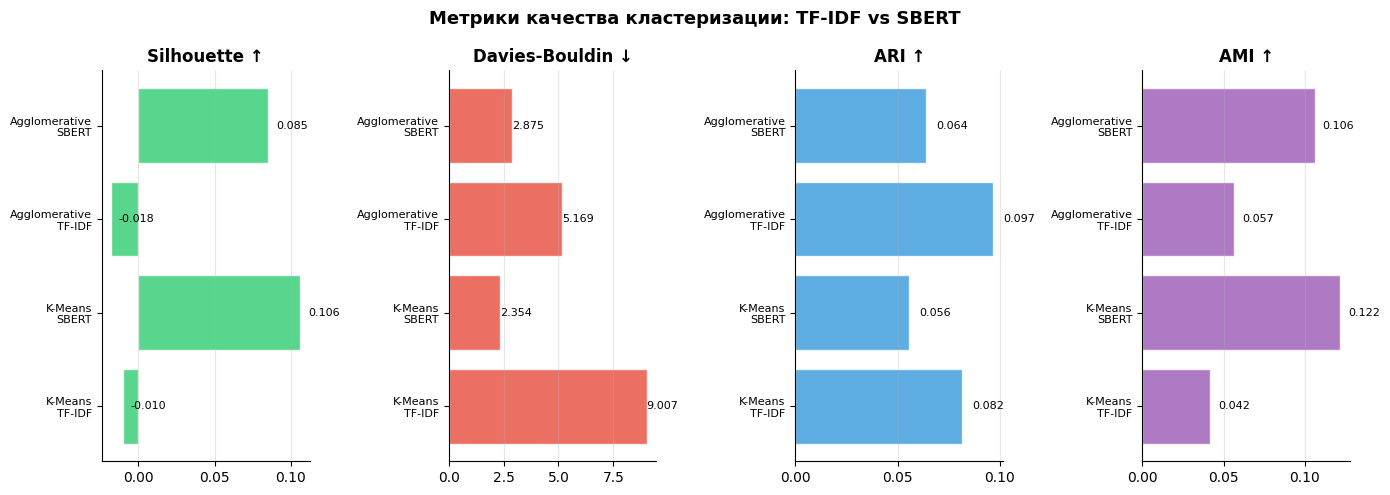

Сохранено: clustering_metrics.png


In [24]:
# 6. Метрики качества кластеризации (без HDBSCAN)

def evaluate_clustering(X, pred_labels, true_labels, method_name,
                         sample_size=3000, metric='cosine'):
    """Считает все метрики качества кластеризации."""
    result = {'method': method_name}

    # Silhouette и Davies-Bouldin — на выборке для скорости
    if X.shape[0] > sample_size:
        idx = np.random.RandomState(42).choice(X.shape[0], sample_size, replace=False)
        X_s, p_s, t_s = X[idx], pred_labels[idx], true_labels[idx]
    else:
        X_s, p_s, t_s = X, pred_labels, true_labels

    # Фильтруем шум (если есть)
    mask = p_s != -1
    if mask.sum() < 2 or len(set(p_s[mask])) < 2:
        result['silhouette'] = None
        result['davies_bouldin'] = None
    else:
        result['silhouette']     = silhouette_score(X_s[mask], p_s[mask], metric=metric)
        result['davies_bouldin'] = davies_bouldin_score(X_s[mask], p_s[mask])

    # ARI и AMI — по всем документам
    mask_full = pred_labels != -1
    result['ari'] = adjusted_rand_score(true_labels[mask_full], pred_labels[mask_full])
    result['ami'] = adjusted_mutual_info_score(true_labels[mask_full], pred_labels[mask_full])
    result['n_clusters'] = len(set(pred_labels[mask_full]))

    return result


results = []

# K-Means
results.append(evaluate_clustering(X_tfidf, labels_km_tfidf, all_labels,
                                    'K-Means  |  TF-IDF'))
results.append(evaluate_clustering(X_sbert, labels_km_sbert, all_labels,
                                    'K-Means  |  SBERT',  metric='euclidean'))

# Agglomerative (на выборке)
results.append(evaluate_clustering(X_tfidf[idx_agg_sorted], labels_agg_tfidf_sample,
                                    true_labels_agg_sample,
                                    'Agglomerative  |  TF-IDF'))
results.append(evaluate_clustering(X_sbert[idx_agg_sorted], labels_agg_sbert_sample,
                                    true_labels_agg_sample,
                                    'Agglomerative  |  SBERT', metric='euclidean'))

df_metrics = pd.DataFrame(results)
df_metrics = df_metrics.set_index('method')

print('\n══════════════════════ МЕТРИКИ КАЧЕСТВА ══════════════════════')
print(df_metrics.to_string(float_format=lambda x: f'{x:.4f}' if x else 'N/A'))

# Визуализация
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
metric_names = ['silhouette', 'davies_bouldin', 'ari', 'ami']
metric_labels = ['Silhouette ↑', 'Davies-Bouldin ↓', 'ARI ↑', 'AMI ↑']
bar_colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

for ax, metric, mlabel, color in zip(axes, metric_names, metric_labels, bar_colors):
    vals = df_metrics[metric].dropna()
    short_names = [m.split('|')[0].strip() + '\n' + m.split('|')[1].strip()
                   for m in vals.index]
    bars = ax.barh(range(len(vals)), vals.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_title(mlabel, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, (bar, val) in enumerate(zip(bars, vals.values)):
        ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Метрики качества кластеризации: TF-IDF vs SBERT',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: clustering_metrics.png')

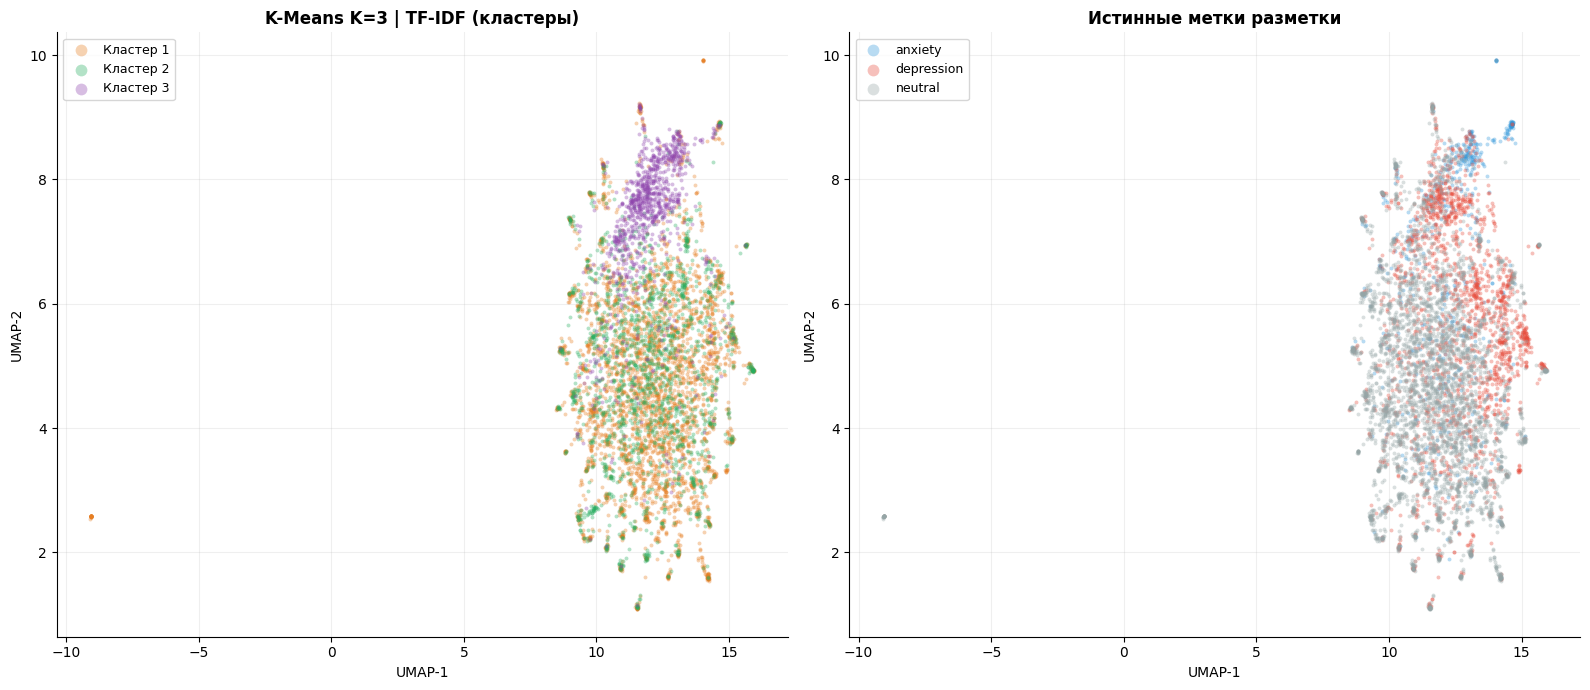

Сохранено: umap_kmeans_tfidf.png


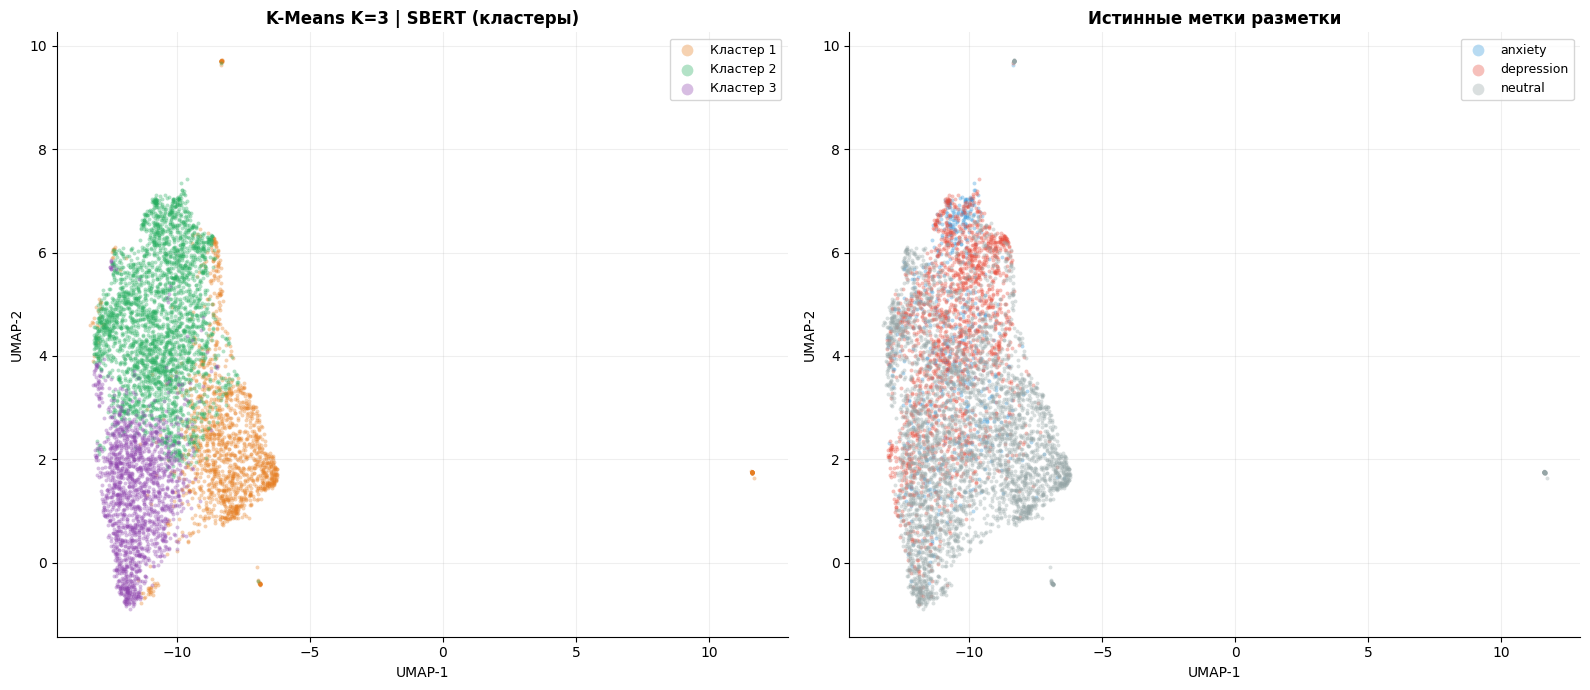

Сохранено: umap_kmeans_sbert.png


In [25]:
# 7. Визуализация кластеров K-Means на UMAP

CLUSTER_COLORS = ['#e67e22', '#27ae60', '#8e44ad', '#2980b9', '#c0392b']

def plot_clusters_vs_labels(coords, cluster_labels, true_label_names,
                             title_cluster, title_true, colors_true, save_path):
    """Два графика рядом: кластеры (предсказанные) vs истинные метки."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Левый: предсказанные кластеры
    ax = axes[0]
    unique_clusters = sorted(set(cluster_labels))
    for i, c in enumerate(unique_clusters):
        mask = cluster_labels == c
        label = f'Шум (выброс)' if c == -1 else f'Кластер {c+1}'
        color = '#cccccc' if c == -1 else CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, alpha=0.35, s=8, label=label,
                   linewidths=0, rasterized=True)
    ax.set_title(title_cluster, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9, markerscale=3)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Правый: истинные метки
    ax2 = axes[1]
    for lname in sorted(set(true_label_names)):
        mask = np.array(true_label_names) == lname
        ax2.scatter(coords[mask, 0], coords[mask, 1],
                    c=colors_true[lname], alpha=0.35, s=8, label=lname,
                    linewidths=0, rasterized=True)
    ax2.set_title(title_true, fontweight='bold', fontsize=12)
    ax2.legend(fontsize=9, markerscale=3)
    ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2')
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {save_path.name}')


# TF-IDF K-Means
plot_clusters_vs_labels(
    umap_tfidf, labels_km_tfidf, all_label_names,
    'K-Means K=3 | TF-IDF (кластеры)',
    'Истинные метки разметки',
    COLORS, SAVE_DIR / 'umap_kmeans_tfidf.png'
)

# SBERT K-Means
plot_clusters_vs_labels(
    umap_sbert, labels_km_sbert, all_label_names,
    'K-Means K=3 | SBERT (кластеры)',
    'Истинные метки разметки',
    COLORS, SAVE_DIR / 'umap_kmeans_sbert.png'
)

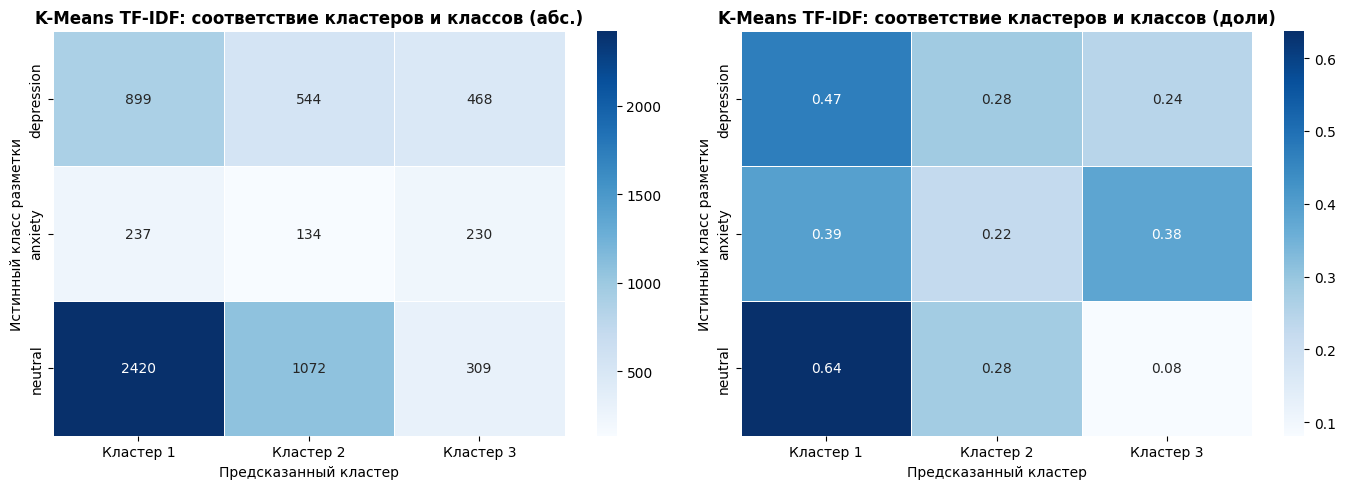

Сохранено: confusion_kmeans_tfidf.png


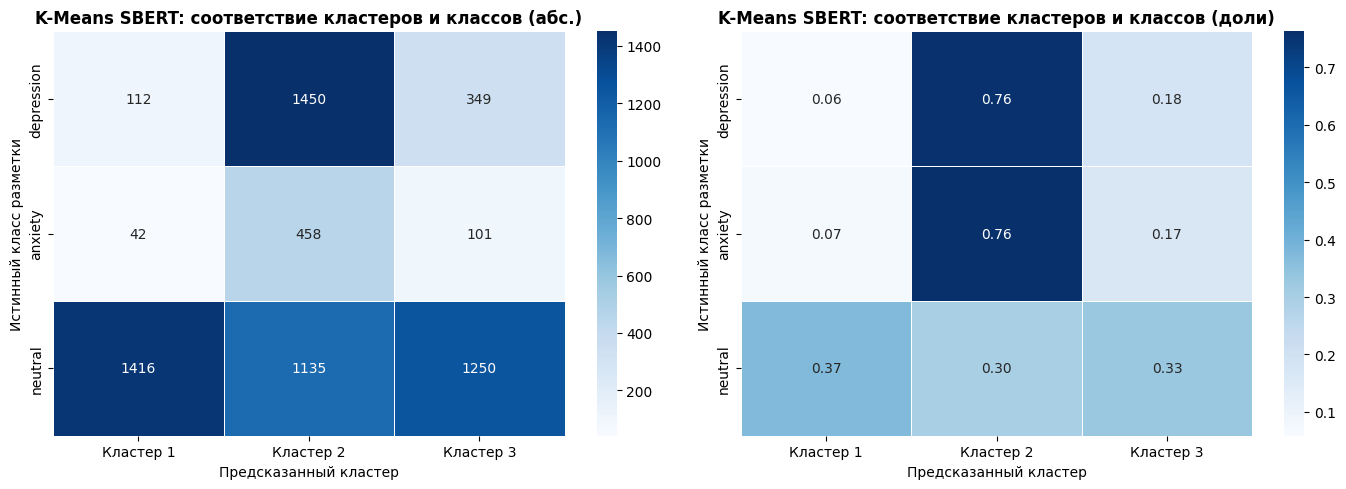

Сохранено: confusion_kmeans_sbert.png


In [26]:
# 8. Анализ соответствия кластеров и меток

"""
Матрица confusion — показывает, какой кластер соответствует какому классу разметки. Если кластеризация хорошо работает — каждый кластер будет доминировать в одном классе.
"""

from scipy.optimize import linear_sum_assignment

def best_label_mapping(true_labels, pred_labels):
    """Находит оптимальное соответствие кластеров и истинных меток (венгерский алгоритм)."""
    mask = pred_labels != -1
    t, p = true_labels[mask], pred_labels[mask]
    n = max(t.max(), p.max()) + 1
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = -np.sum((t == i) & (p == j))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return mapping


def plot_confusion_heatmap(true_labels, pred_labels, class_names,
                            title, save_path):
    mask = pred_labels != -1
    cm = confusion_matrix(true_labels[mask], pred_labels[mask])
    # Нормализуем по строкам (по истинному классу)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    cluster_names = [f'Кластер {i+1}' for i in range(cm.shape[1])]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, t in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        [f'{title} (абс.)', f'{title} (доли)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=cluster_names,
                    yticklabels=class_names,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel('Предсказанный кластер')
        ax.set_ylabel('Истинный класс разметки')
        ax.set_title(t, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {save_path.name}')


plot_confusion_heatmap(
    all_labels, labels_km_tfidf, CLASSES,
    'K-Means TF-IDF: соответствие кластеров и классов',
    SAVE_DIR / 'confusion_kmeans_tfidf.png'
)

plot_confusion_heatmap(
    all_labels, labels_km_sbert, CLASSES,
    'K-Means SBERT: соответствие кластеров и классов',
    SAVE_DIR / 'confusion_kmeans_sbert.png'
)

Топ-слова кластеров K-Means SBERT (оригинальные тексты):

Кластер 1 (доминирует: neutral)
  большое (22.8) | телеграмм (21.0) | надеюсь (19.2) | тоже (17.7) | телеграм (16.5) | себя (13.8) | сколько (13.1) | время (12.1) | думаю (11.4) | лучше (10.8) | желаю (10.2) | этого (10.2) | стоит (9.8) | хотя (9.8) | этом (9.7)

Кластер 2 (доминирует: depression)
  депрессия (78.3) | себя (66.1) | депрессии (51.2) | себе (49.3) | тоже (49.0) | этого (43.8) | лучше (42.6) | жизни (42.0) | время (41.6) | этом (40.7) | после (40.7) | больше (40.2) | человек (38.8) | которые (38.8) | жизнь (38.3)

Кластер 3 (доминирует: neutral)
  ничего (34.6) | тоже (28.1) | знаю (23.6) | себя (19.9) | себе (19.2) | лучше (18.8) | хотя (17.3) | жизни (16.3) | жизнь (16.2) | делать (16.0) | людей (15.4) | такое (15.2) | этого (14.1) | этом (14.1) | люди (13.9)


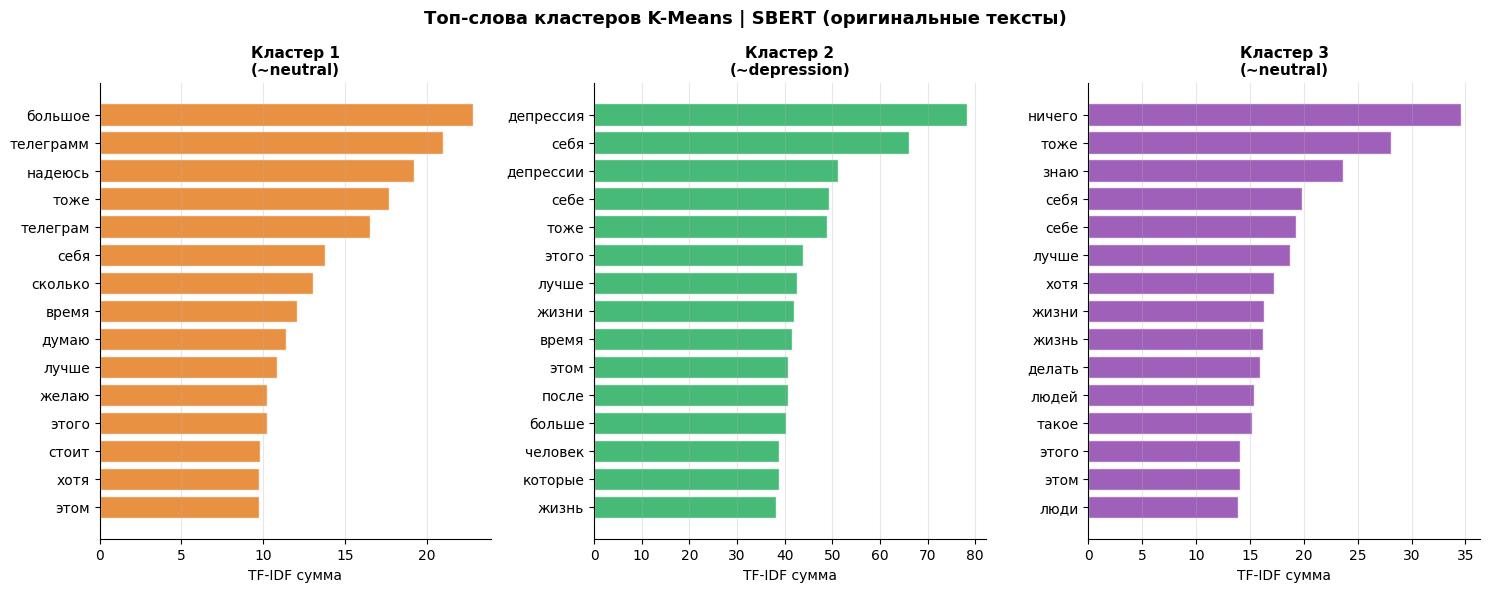

Сохранено: cluster_words_sbert.png

Топ-слова кластеров K-Means TF-IDF (лемматизированные тексты):

Кластер 1 (доминирует: neutral)
  человек (74.2) | депрессия (64.3) | хотеть (48.4) | жизнь (47.7) | знать (46.7) | друг (46.0) | который (45.6) | проблема (44.4) | думать (43.0) | время (41.3) | найти (41.2) | психолог (38.2) | психиатр (37.9) | говорить (37.8) | делать (36.6)

Кластер 2 (доминирует: neutral)
  человек (57.7) | депрессия (44.9) | который (34.3) | жизнь (31.9) | сказать (29.6) | говорить (29.0) | хотеть (28.8) | знать (28.5) | думать (28.0) | проблема (27.8) | понимать (26.7) | делать (26.5) | время (22.9) | самый (22.8) | отношение (22.2)

Кластер 3 (доминирует: depression)
  человек (64.5) | который (57.8) | депрессия (54.3) | другой (37.0) | жизнь (36.7) | делать (36.1) | тревога (31.2) | время (28.1) | знать (27.6) | хотеть (26.5) | работа (25.7) | эмоция (24.6) | сделать (23.5) | проблема (23.3) | друг (23.1)


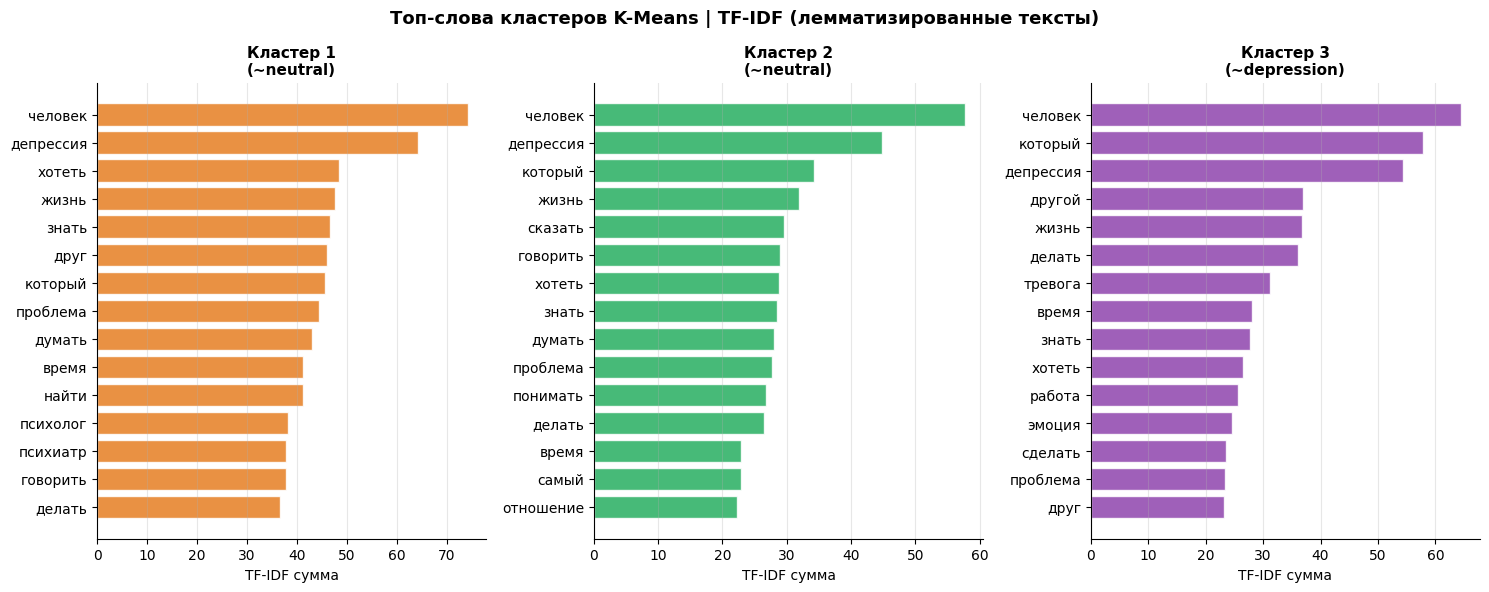

Сохранено: cluster_words_tfidf.png


In [34]:
# 9. Характеристика кластеров: топ-слова (максимальная фильтрация) + визуализация

# Максимальный список стоп-слов
MAX_STOP_WORDS = {
    # Союзы и предлоги
    'и', 'в', 'во', 'с', 'со', 'а', 'но', 'да', 'за', 'по', 'из', 'от', 'до',
    'у', 'о', 'об', 'без', 'для', 'про', 'через', 'между', 'перед', 'при',
    'к', 'на', 'под', 'над', 'около', 'возле', 'мимо', 'вне', 'внутри',
    'или', 'либо', 'если', 'когда', 'чтобы', 'потому', 'так как', 'будто',

    # Частицы и междометия
    'не', 'ни', 'бы', 'б', 'же', 'ж', 'ли', 'ль', 'ведь', 'вон', 'вот',
    'даже', 'именно', 'только', 'лишь', 'почти', 'уже', 'ещё',
    'вдруг', 'разве', 'неужели', 'ну', 'ага', 'угу', 'ок', 'окей', 'ладно',

    # Местоимения
    'я', 'ты', 'он', 'она', 'оно', 'мы', 'вы', 'они',
    'меня', 'тебя', 'его', 'её', 'ее', 'нас', 'вас', 'их',
    'мне', 'тебе', 'ему', 'ей', 'нам', 'вам', 'им',
    'мой', 'твой', 'наш', 'ваш',
    'свой', 'сам', 'сама', 'сами',
    'этот', 'эта', 'это', 'эти', 'тот', 'та', 'то', 'те',
    'кто', 'что', 'какой', 'такой', 'весь', 'вся', 'все', 'всё',

    # Наречия
    'так', 'как', 'где', 'куда', 'откуда', 'зачем', 'почему', 'потому',
    'поэтому', 'тогда', 'сейчас', 'теперь', 'потом', 'всегда', 'никогда',
    'иногда', 'часто', 'редко', 'много', 'мало', 'очень', 'слишком',
    'довольно', 'совсем', 'абсолютно', 'почти', 'приблизительно',
    'просто', 'тут', 'там', 'здесь', 'везде', 'всюду', 'нигде',

    # Глаголы-связки
    'быть', 'есть', 'был', 'была', 'было', 'были', 'будет', 'будут',
    'стать', 'стал', 'стала', 'стало', 'стали', 'становиться',
    'мочь', 'могу', 'можешь', 'может', 'можем', 'могут', 'мог', 'могла', 'могли',
    'иметь', 'имею', 'имеешь', 'имеет', 'имеем', 'имеют', 'имел',

    # Модальные слова
    'можно', 'нельзя', 'надо', 'нужно', 'должен', 'должна', 'должно', 'должны',
    'нужен', 'нужна', 'нужно', 'нужны',

    # Вводные слова
    'конечно', 'разумеется', 'безусловно', 'вероятно', 'возможно',
    'наверное', 'кажется', 'казалось', 'может', 'может быть',
    'наверно', 'наверняка', 'действительно', 'правда', 'честно',
    'вообще', 'вроде', 'как бы', 'так сказать',

    # Прочие высокочастотные
    'спасибо', 'пожалуйста', 'извините', 'здравствуйте', 'до свидания',
    'да', 'нет', 'нормально', 'хорошо', 'плохо', 'так себе',
    'раз', 'два', 'три', 'первый', 'второй', 'третий',
    'this', 'https', 'http', 'com', 'ru', 'rusaskreddit', 'канал', 'удачи', 'ответ', 'message', 'moderators', 'action', 'performed', 'please', 'contact', 'concerns', 'compose', 'automatically', 'subreddit', 'questions', 'have',
    'rusask', 'otify', 'reddit',
}

def get_cluster_top_words_clean(cluster_labels, texts, n_words=20):
    """Топ-слова кластеров с максимальной фильтрацией."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from collections import Counter

    # Создаём векторизатор с жёсткими параметрами
    vectorizer = TfidfVectorizer(
        min_df=3,
        max_df=0.3,
        max_features=3000,
        stop_words=list(MAX_STOP_WORDS),
        token_pattern=r'(?u)\b\w{4,}\b'
    )

    X = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())

    cluster_words = {}
    for c in sorted(set(cluster_labels)):
        if c == -1:
            continue
        mask = cluster_labels == c
        if mask.sum() < 5:
            continue

        cluster_sum = np.asarray(X[mask].sum(axis=0)).flatten()
        top_idx = cluster_sum.argsort()[::-1][:n_words]

        words_with_weights = [(feature_names[i], cluster_sum[i])
                               for i in top_idx if cluster_sum[i] > 0]
        cluster_words[c] = words_with_weights

    return cluster_words, vectorizer

def plot_cluster_words(cluster_words, cluster_labels, label_names_list,
                        title, save_path, n_words=15):
    """Визуализация топ-слов кластеров в виде barplot."""
    n_clusters = len(cluster_words)
    fig, axes = plt.subplots(1, n_clusters, figsize=(n_clusters * 5, 6))
    if n_clusters == 1:
        axes = [axes]

    palette = ['#e67e22', '#27ae60', '#8e44ad', '#2980b9', '#c0392b']

    for ax, (c, words), color in zip(axes, cluster_words.items(), palette):
        from collections import Counter
        cluster_mask = cluster_labels == c
        labels_in_cluster = [label_names_list[i] for i in range(len(label_names_list)) if cluster_mask[i]]
        dominant = Counter(labels_in_cluster).most_common(1)[0][0] if labels_in_cluster else 'unknown'

        ws = [w for w, _ in words[:n_words]]
        vs = [v for _, v in words[:n_words]]

        ax.barh(range(len(ws)), vs, color=color, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(ws)))
        ax.set_yticklabels(ws, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f'Кластер {c+1}\n(∼{dominant})', fontweight='bold', fontsize=11)
        ax.set_xlabel('TF-IDF сумма')
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {save_path.name}')

# ========== SBERT ==========
print('='*60)
print('Топ-слова кластеров K-Means SBERT (оригинальные тексты):')
print('='*60)

cwords_sbert_clean, _ = get_cluster_top_words_clean(labels_km_sbert, all_texts_original)

for c, words in cwords_sbert_clean.items():
    from collections import Counter
    cluster_mask = labels_km_sbert == c
    labels_in_cluster = [all_label_names[i] for i in range(len(all_label_names)) if cluster_mask[i]]
    dominant = Counter(labels_in_cluster).most_common(1)[0][0] if labels_in_cluster else 'unknown'

    print(f'\nКластер {c+1} (доминирует: {dominant})')
    significant = [(w, s) for w, s in words if s > 5][:15]
    if significant:
        print('  ' + ' | '.join(f'{w} ({s:.1f})' for w, s in significant))
    else:
        print('  ' + ' | '.join(f'{w} ({s:.1f})' for w, s in words[:15]))

# График для SBERT
plot_cluster_words(
    cwords_sbert_clean, labels_km_sbert, all_label_names,
    'Топ-слова кластеров K-Means | SBERT (оригинальные тексты)',
    SAVE_DIR / 'cluster_words_sbert.png',
    n_words=15
)

# ========== TF-IDF ==========
print('\n' + '='*60)
print('Топ-слова кластеров K-Means TF-IDF (лемматизированные тексты):')
print('='*60)

cwords_tfidf_clean, _ = get_cluster_top_words_clean(labels_km_tfidf, all_texts_lemma)

for c, words in cwords_tfidf_clean.items():
    from collections import Counter
    cluster_mask = labels_km_tfidf == c
    labels_in_cluster = [all_label_names[i] for i in range(len(all_label_names)) if cluster_mask[i]]
    dominant = Counter(labels_in_cluster).most_common(1)[0][0] if labels_in_cluster else 'unknown'

    print(f'\nКластер {c+1} (доминирует: {dominant})')
    significant = [(w, s) for w, s in words if s > 5][:15]
    if significant:
        print('  ' + ' | '.join(f'{w} ({s:.1f})' for w, s in significant))
    else:
        print('  ' + ' | '.join(f'{w} ({s:.1f})' for w, s in words[:15]))

# График для TF-IDF
plot_cluster_words(
    cwords_tfidf_clean, labels_km_tfidf, all_label_names,
    'Топ-слова кластеров K-Means | TF-IDF (лемматизированные тексты)',
    SAVE_DIR / 'cluster_words_tfidf.png',
    n_words=15
)

In [37]:
# 11. Сохранение результатов в Excel (с чистыми топ-словами + confusion matrix)

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from sklearn.metrics import confusion_matrix

wb = openpyxl.Workbook()

# ── Лист 1: Метрики качества ─────────────────────────────────────────────
ws_m = wb.active
ws_m.title = 'metrics'
ws_m.append(['Метод', 'Silhouette ↑', 'Davies-Bouldin ↓', 'ARI ↑', 'AMI ↑', 'N кластеров'])
for col in range(1, 7):
    ws_m.cell(1, col).font = Font(bold=True)
    ws_m.cell(1, col).fill = PatternFill(start_color='D6E4F0', fill_type='solid')

for method, row in df_metrics.iterrows():
    ws_m.append([
        method,
        round(row['silhouette'], 4) if row['silhouette'] else 'N/A',
        round(row['davies_bouldin'], 4) if row['davies_bouldin'] else 'N/A',
        round(row['ari'], 4),
        round(row['ami'], 4),
        int(row['n_clusters'])
    ])
for col in range(1, 7):
    ws_m.column_dimensions[get_column_letter(col)].width = 28

# ── Лист 2: Confusion Matrix K-Means TF-IDF ──────────────────────────────
ws_cm_tfidf = wb.create_sheet('confusion_kmeans_tfidf')
ws_cm_tfidf.append(['Confusion Matrix K-Means TF-IDF', '', '', ''])
ws_cm_tfidf.cell(1, 1).font = Font(bold=True)

# Строим confusion matrix
cm_tfidf = confusion_matrix(all_labels, labels_km_tfidf)
class_names = ['depression', 'anxiety', 'neutral']

# Заголовки
ws_cm_tfidf.append([''] + [f'Кластер {i+1}' for i in range(cm_tfidf.shape[1])])
for i, name in enumerate(class_names):
    row = [name] + [int(cm_tfidf[i, j]) for j in range(cm_tfidf.shape[1])]
    ws_cm_tfidf.append(row)

# Добавляем строку с totals
ws_cm_tfidf.append(['Total'] + [int(cm_tfidf[:, j].sum()) for j in range(cm_tfidf.shape[1])])

for col in range(1, 5):
    ws_cm_tfidf.column_dimensions[get_column_letter(col)].width = 18

# ── Лист 3: Confusion Matrix K-Means SBERT ──────────────────────────────
ws_cm_sbert = wb.create_sheet('confusion_kmeans_sbert')
ws_cm_sbert.append(['Confusion Matrix K-Means SBERT', '', '', ''])
ws_cm_sbert.cell(1, 1).font = Font(bold=True)

cm_sbert = confusion_matrix(all_labels, labels_km_sbert)

ws_cm_sbert.append([''] + [f'Кластер {i+1}' for i in range(cm_sbert.shape[1])])
for i, name in enumerate(class_names):
    row = [name] + [int(cm_sbert[i, j]) for j in range(cm_sbert.shape[1])]
    ws_cm_sbert.append(row)

ws_cm_sbert.append(['Total'] + [int(cm_sbert[:, j].sum()) for j in range(cm_sbert.shape[1])])

for col in range(1, 5):
    ws_cm_sbert.column_dimensions[get_column_letter(col)].width = 18

# ── Лист 4: Топ-слова кластеров SBERT (чистые) ──────────────────────────
ws_sbert = wb.create_sheet('cluster_words_sbert')
ws_sbert.append(['Кластер', 'Доминирующий класс', 'Топ-слова (слово: вес)'])
ws_sbert.cell(1, 1).font = Font(bold=True)

for c, words in cwords_sbert_clean.items():
    from collections import Counter
    cluster_mask = labels_km_sbert == c
    labels_in_cluster = [all_label_names[i] for i in range(len(all_label_names)) if cluster_mask[i]]
    dominant = Counter(labels_in_cluster).most_common(1)[0][0] if labels_in_cluster else 'unknown'

    words_str = ' | '.join(f'{w}: {s:.1f}' for w, s in words[:20])
    ws_sbert.append([f'Кластер {c+1}', dominant, words_str])

for col in [1, 2, 3]:
    ws_sbert.column_dimensions[get_column_letter(col)].width = [15, 20, 120][col-1]

# ── Лист 5: Топ-слова кластеров TF-IDF (чистые) ──────────────────────────
ws_tfidf = wb.create_sheet('cluster_words_tfidf')
ws_tfidf.append(['Кластер', 'Доминирующий класс', 'Топ-слова (слово: вес)'])
ws_tfidf.cell(1, 1).font = Font(bold=True)

for c, words in cwords_tfidf_clean.items():
    from collections import Counter
    cluster_mask = labels_km_tfidf == c
    labels_in_cluster = [all_label_names[i] for i in range(len(all_label_names)) if cluster_mask[i]]
    dominant = Counter(labels_in_cluster).most_common(1)[0][0] if labels_in_cluster else 'unknown'

    words_str = ' | '.join(f'{w}: {s:.1f}' for w, s in words[:20])
    ws_tfidf.append([f'Кластер {c+1}', dominant, words_str])

for col in [1, 2, 3]:
    ws_tfidf.column_dimensions[get_column_letter(col)].width = [15, 20, 120][col-1]

# ── Лист 6: Метки по документам ──────────────────────────────────────────
ws_d = wb.create_sheet('document_labels')
ws_d.append(['doc_id', 'true_label', 'kmeans_tfidf', 'kmeans_sbert'])
ws_d.cell(1, 1).font = Font(bold=True)

for i in range(len(all_label_names)):
    ws_d.append([
        i,
        all_label_names[i],
        int(labels_km_tfidf[i] + 1),
        int(labels_km_sbert[i] + 1)
    ])

for col in [1, 2, 3, 4]:
    ws_d.column_dimensions[get_column_letter(col)].width = [15, 15, 15, 15][col-1]

# Удаляем старый дефолтный лист
if 'Sheet' in wb.sheetnames:
    del wb['Sheet']

# Сохраняем
SAVE_DIR = Path('/content/drive/MyDrive/SFU 4/VKR/8. Clustering')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

wb.save(SAVE_DIR / 'clustering_results_clean.xlsx')
print('Сохранено: clustering_results_clean.xlsx')
print(f'\nЛисты в файле:')
for sheet in wb.sheetnames:
    print(f'  - {sheet}')

Сохранено: clustering_results_clean.xlsx

Листы в файле:
  - metrics
  - confusion_kmeans_tfidf
  - confusion_kmeans_sbert
  - cluster_words_sbert
  - cluster_words_tfidf
  - document_labels


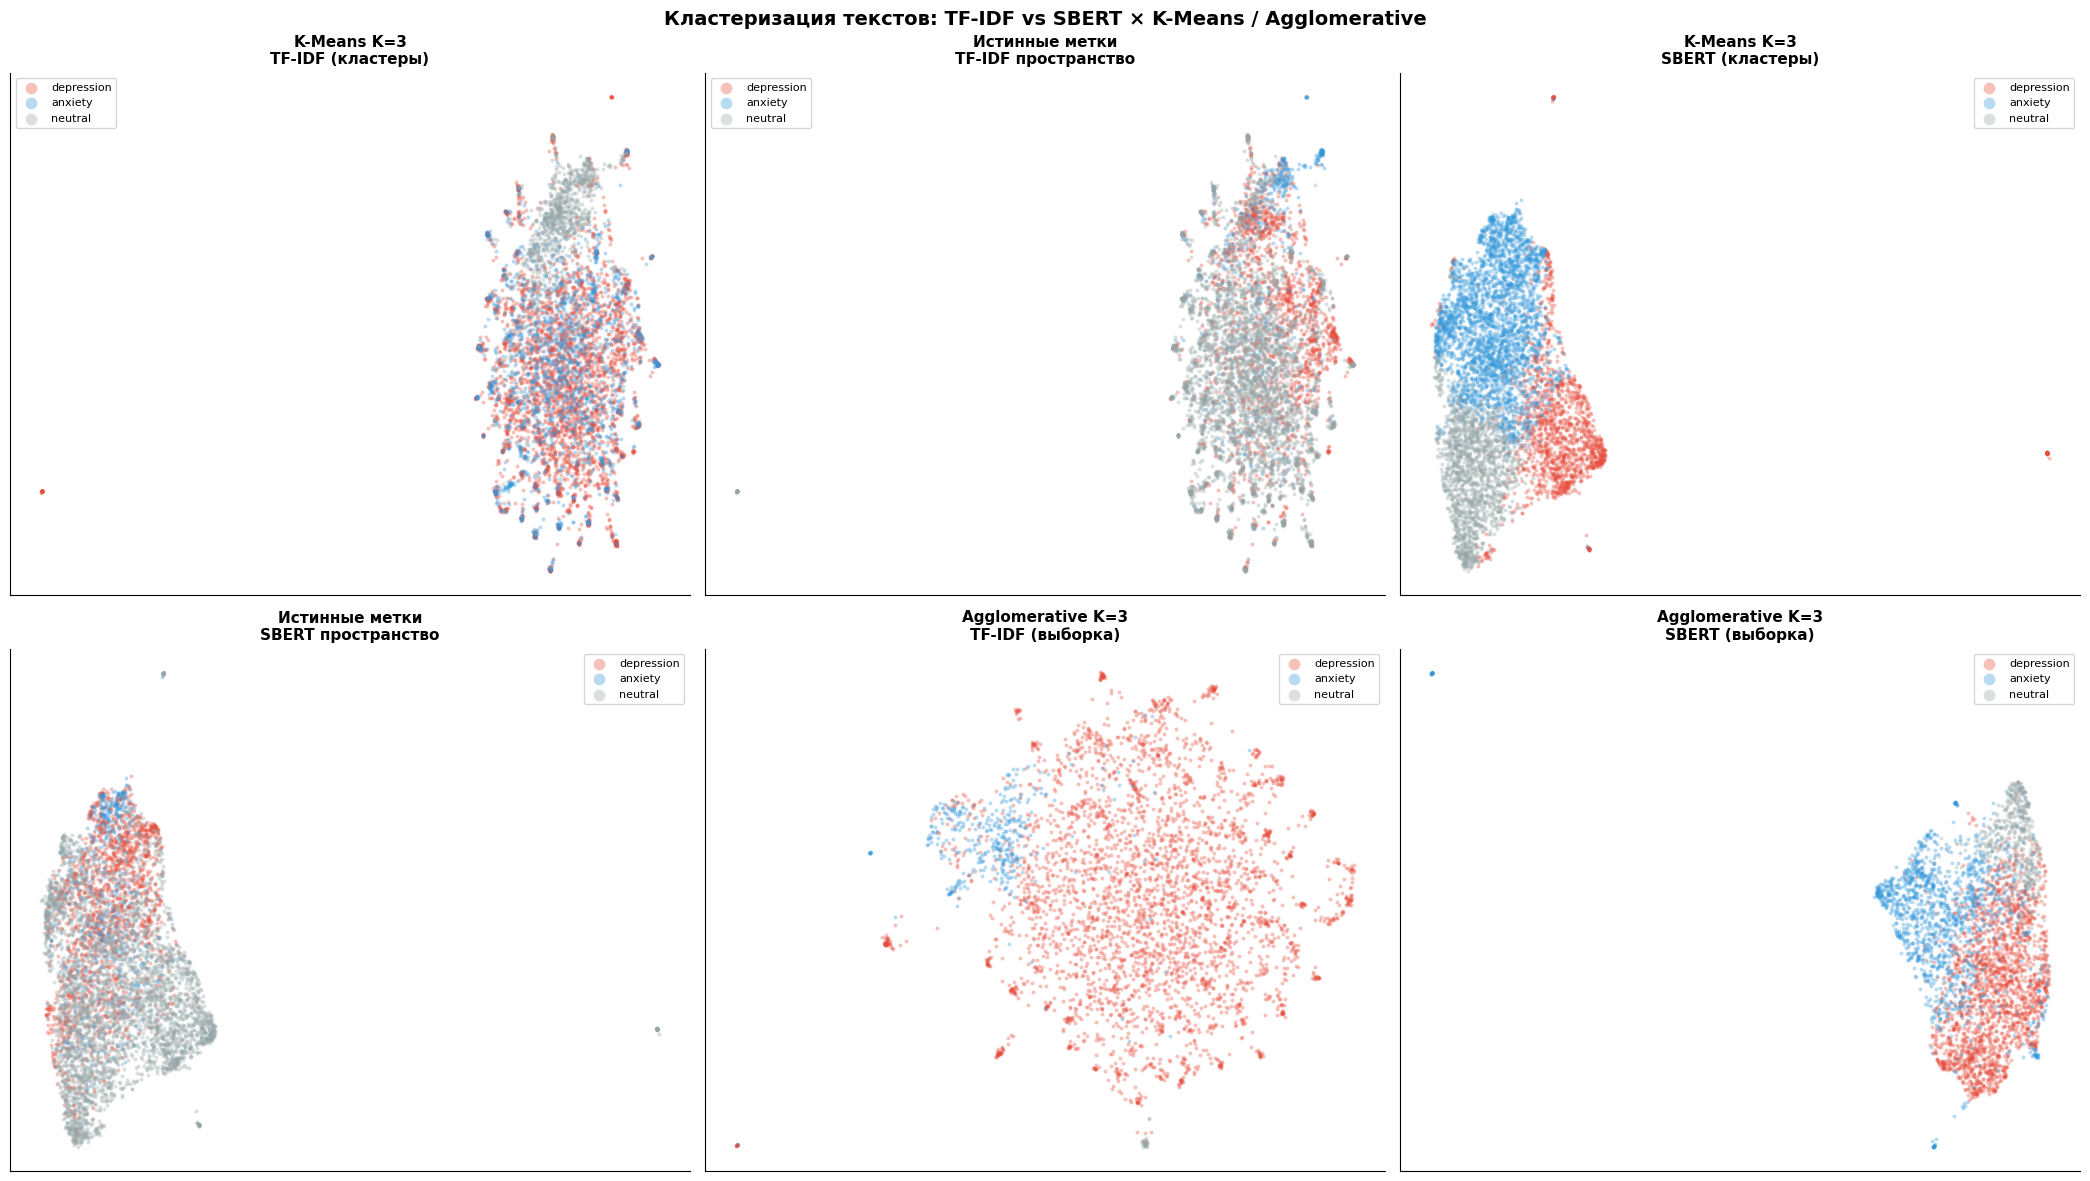

Сохранено: clustering_overview.png


In [38]:
# 11. Итоговое сравнение (без HDBSCAN, 2 строки × 3 столбца)

# Создаём UMAP для агрегативной выборки отдельно
umap_tfidf_agg = reduce_umap(X_tfidf[idx_agg_sorted])
umap_sbert_agg = reduce_umap(X_sbert[idx_agg_sorted])

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

plot_configs = [
    # (coords, cluster_labels, row, col, title)
    (umap_tfidf, labels_km_tfidf,          0, 0, 'K-Means K=3\nTF-IDF (кластеры)'),
    (umap_tfidf, all_labels,               0, 1, 'Истинные метки\nTF-IDF пространство'),
    (umap_sbert, labels_km_sbert,          0, 2, 'K-Means K=3\nSBERT (кластеры)'),
    (umap_sbert, all_labels,               1, 0, 'Истинные метки\nSBERT пространство'),
    (umap_tfidf_agg, labels_agg_tfidf_sample, 1, 1, 'Agglomerative K=3\nTF-IDF (выборка)'),
    (umap_sbert_agg, labels_agg_sbert_sample, 1, 2, 'Agglomerative K=3\nSBERT (выборка)'),
]

cluster_palette_map = {0: '#e67e22', 1: '#27ae60', 2: '#8e44ad', -1: '#cccccc'}
true_int_to_color = {0: '#e74c3c', 1: '#3498db', 2: '#95a5a6'}

for coords, clabels, row, col, title in plot_configs:
    ax = axes[row, col]
    unique = sorted(set(clabels))

    if isinstance(clabels[0], (np.integer, int)):
        # числовые — кластеры или true int labels
        is_true = (max(unique) <= 2 and min(unique) >= 0 and
                   set(unique) == {0, 1, 2})
        for u in unique:
            mask = np.array(clabels) == u
            if is_true:
                c = true_int_to_color.get(u, '#aaa')
                lbl = {0: 'depression', 1: 'anxiety', 2: 'neutral'}.get(u, f'Кластер {u+1}')
            else:
                c = cluster_palette_map.get(u, '#aaa')
                lbl = f'Кластер {u+1}' if u != -1 else 'шум'
            ax.scatter(coords[mask, 0], coords[mask, 1], c=c, alpha=0.35,
                       s=8, label=lbl, linewidths=0, rasterized=True)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, markerscale=3, loc='best')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Кластеризация текстов: TF-IDF vs SBERT × K-Means / Agglomerative',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'clustering_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: clustering_overview.png')

"""
---
## Что смотреть в результатах

### Ключевые вопросы для ВКР:

**1. ARI и AMI** — главные цифры. Если ARI > 0.3 — кластеризация значимо согласуется с разметкой. Если ARI ≈ 0 — кластеры не совпадают с классами (что тоже интересный результат: значит, тексты организованы по другому принципу, чем словарная разметка).

**2. TF-IDF vs SBERT** — сравни Silhouette и ARI. Как правило SBERT даст лучший Silhouette (семантически похожие тексты ближе), но TF-IDF может дать лучший ARI на специфической лексике.

**3. UMAP-визуализации** — смотришь на два графика рядом (кластеры vs истинные метки). Если цвета совпадают — кластеризация нашла то же, что и разметка.

**4. Матрица confusion** — показывает, какой кластер = какой класс. Если depression и anxiety попадают в один кластер — это языковое свидетельство их близости (коморбидность).

**5. Топ-слова кластеров** — сравни с топ-словами LDA. Если пересекаются — методы взаимно верифицируют друг друга.

### Файлы:
| Файл | Содержание |
|------|------------|
| `umap_true_labels.png` | UMAP по истинным меткам: TF-IDF vs SBERT |
| `umap_kmeans_tfidf/sbert.png` | Кластеры K-Means vs истинные метки |
| `clustering_metrics.png` | Сравнение метрик всех методов |
| `confusion_kmeans_*.png` | Матрица соответствия кластеров и классов |
| `cluster_words_*.png` | Топ-слова каждого кластера |
| `dendrogram_sbert.png` | Дендрограмма иерархической кластеризации |
| `clustering_overview.png` | Обзорный рисунок — все методы сразу |
| `clustering_results.xlsx` | Метрики + топ-слова + метки документов |
"""